# Tarea 2: Predicción de la Vida Útil Restante (RUL) mediante Regresión

Este componente se centra en la capa proactiva del sistema de mantenimiento predictivo. A diferencia del detector de anomalías (capa reactiva), el objetivo aquí es estimar cuántos ciclos de funcionamiento le quedan al motor industrial antes de sufrir una avería catastrófica, permitiendo planificar las paradas técnicas de forma óptima.


## 1. Setup

importaciones, la definición de constantes y la exploración de la vida media.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

np.random.seed(42)

DATASET_PATH = "motor_historical.csv"

FEATURES = [
    "vibration_mean", "vibration_std",
    "temperature_mean", "temperature_slope",
    "current_mean", "current_std",
]
TARGET = "RUL"
UMBRAL_TRAMO_FINAL = 50

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 90

## 2. Exploracion del dataset:

In [2]:
df = pd.read_csv(DATASET_PATH)
print(f"Filas totales: {len(df):,}")
print(f"Motores únicos: {df['motor_id'].nunique()}")
print(f"Columnas: {list(df.columns)}")
df.head()



Filas totales: 101,163
Motores únicos: 500
Columnas: ['motor_id', 'cycle', 'vibration_mean', 'vibration_std', 'temperature_mean', 'temperature_slope', 'current_mean', 'current_std', 'RUL']


,motor_id,cycle,vibration_mean,vibration_std,temperature_mean,temperature_slope,current_mean,current_std,RUL
0,1,1,2.745,0.2885,40.95,0.0133,4.320,0.1144,125
1,1,2,2.779,0.3320,41.26,0.0098,4.370,0.1039,125
2,1,3,2.512,0.3368,41.25,-0.0028,4.313,0.1432,125
3,1,4,2.569,0.3050,42.08,0.0295,4.296,0.1651,125
4,1,5,2.333,0.3243,40.33,0.0251,4.458,0.1600,125


Vida media: 202.3 ciclos


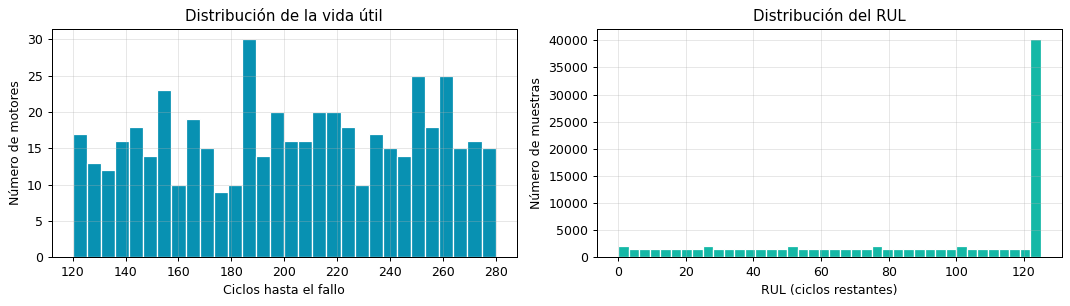

In [3]:
# Vida media y distribución
vidas = df.groupby("motor_id")["cycle"].max()
print(f"Vida media: {vidas.mean():.1f} ciclos")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(vidas, bins=30, color="#0891B2", edgecolor="white")
axes[0].set_xlabel("Ciclos hasta el fallo")
axes[0].set_ylabel("Número de motores")
axes[0].set_title("Distribución de la vida útil")
axes[0].grid(alpha=0.3)

axes[1].hist(df["RUL"], bins=40, color="#14B8A6", edgecolor="white")
axes[1].set_xlabel("RUL (ciclos restantes)")
axes[1].set_ylabel("Número de muestras")
axes[1].set_title("Distribución del RUL")
axes[1].grid(alpha=0.3)

plt.tight_layout()

## 3. Visualización de la Degradación
Antes de entrenar, analizamos visualmente cómo evolucionan las características (*features*) de un motor a lo largo de su vida útil. Observamos el momento en el que el RUL baja de 125 (fin del capping), que es cuando la degradación física debería empezar a ser patente en los sensores.

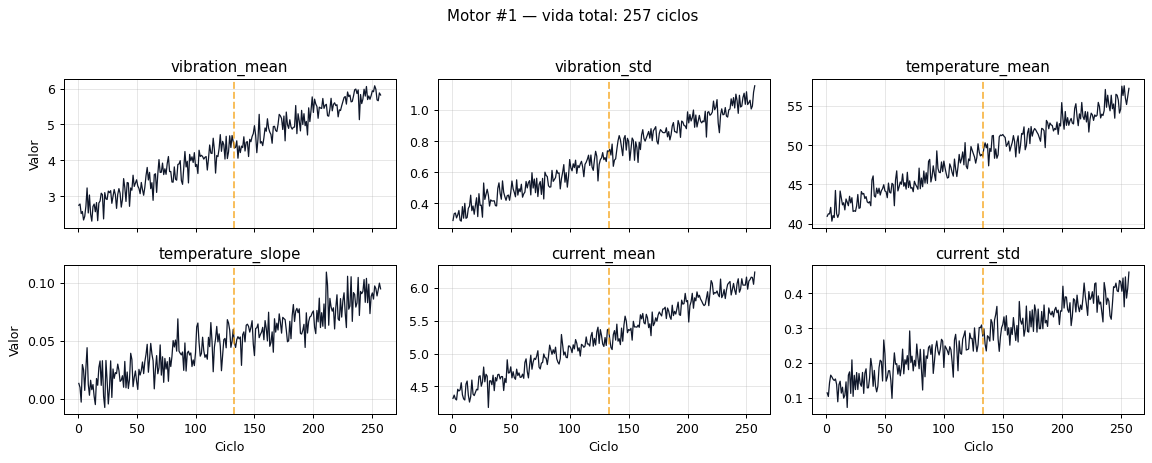

In [4]:
def plot_motor(motor_id, df):
    m = df[df["motor_id"] == motor_id].sort_values("cycle")
    out_cap = m[m["RUL"] < 125]["cycle"].min()

    fig, axes = plt.subplots(2, 3, figsize=(13, 5), sharex=True)
    axes = axes.flatten()
    for ax, feat in zip(axes, FEATURES):
        ax.plot(m["cycle"], m[feat], color="#0F172A", linewidth=1)
        if pd.notna(out_cap):
            ax.axvline(out_cap, color="#F59E0B", linestyle="--", alpha=0.7, label="Fin capping")
        ax.set_title(feat)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Valor")
    axes[3].set_ylabel("Valor")
    for ax in axes[3:]:
        ax.set_xlabel("Ciclo")
    plt.suptitle(f"Motor #{motor_id} — vida total: {m['cycle'].max()} ciclos", y=1.02)
    plt.tight_layout()
    plt.show()

plot_motor(motor_id=1, df=df)

## 4. División de Datos y Funciones de Evaluación
Se realiza un *split* estricto por `motor_id` para evitar fuga de datos. Además, se define la función de evaluación que prioriza el MAE en los últimos 30 ciclos, ya que el error cerca del fallo es el más crítico para la planificación operativa.

In [5]:
def split_by_motor(df, test_frac=0.2, seed=42):
    motores = df["motor_id"].unique()
    rng = np.random.default_rng(seed)
    motores_shuffled = rng.permutation(motores)
    n_test = int(len(motores) * test_frac)
    motores_test = set(motores_shuffled[:n_test])
    motores_train = set(motores_shuffled[n_test:])

    df_train = df[df["motor_id"].isin(motores_train)].copy()
    df_test = df[df["motor_id"].isin(motores_test)].copy()
    return df_train, df_test

def evaluar(modelo, X_test, y_test, umbral_tramo_final=UMBRAL_TRAMO_FINAL):
    y_pred = modelo.predict(X_test)
    mae_global = mean_absolute_error(y_test, y_pred)

    mask_tramo_final = y_test <= umbral_tramo_final
    if mask_tramo_final.sum() == 0:
        mae_tramo_final = np.nan
    else:
        mae_tramo_final = mean_absolute_error(
            y_test[mask_tramo_final], y_pred[mask_tramo_final]
        )

    return {
        "mae_global": mae_global,
        "mae_tramo_final": mae_tramo_final,
        "umbral": umbral_tramo_final,
        "n_test": len(y_test),
        "n_tramo_final": int(mask_tramo_final.sum()),
    }

def plot_predicciones(modelo, df_test, motor_id):
    m = df_test[df_test["motor_id"] == motor_id].sort_values("cycle")
    X_m = m[FEATURES].values
    y_real = m[TARGET].values
    y_pred = modelo.predict(X_m)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(m["cycle"], y_real, color="#0F172A", linewidth=1.8, label="RUL real")
    ax.plot(m["cycle"], y_pred, color="#0891B2", linewidth=1.5, linestyle="--", label="RUL predicho")
    ax.axhline(125, color="#F59E0B", linestyle=":", alpha=0.5, label="Cap = 125")
    ax.set_xlabel("Ciclo")
    ax.set_ylabel("RUL")
    ax.set_title(f"Predicción RUL - Motor #{motor_id}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

df_train, df_test = split_by_motor(df, test_frac=0.2, seed=42)
X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values
X_test = df_test[FEATURES].values
y_test = df_test[TARGET].values

print(f"Train: {len(df_train):,} filas, {df_train['motor_id'].nunique()} motores")
print(f"Test:  {len(df_test):,} filas, {df_test['motor_id'].nunique()} motores")

Train: 81,206 filas, 400 motores
Test:  19,957 filas, 100 motores


## 5. Entrenamiento y Comparativa de Modelos

Para cuantificar el valor de usar algoritmos más avanzados, primero entrenamos un modelo base (*baseline*) utilizando una **Regresión Lineal**. Posteriormente, entrenamos un **Random Forest**, un modelo capaz de capturar relaciones no lineales entre las variables físicas (como la aceleración del desgaste térmico o vibracional).

El éxito de ambos modelos se medirá priorizando el MAE (Error Absoluto Medio) en los últimos 30 ciclos de vida, ya que fallar al predecir el inicio de la vida útil carece de impacto operativo, pero fallar cerca del momento de la rotura implica un alto coste.

In [6]:
# 1. Regresión Lineal (Baseline)
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
res_lr = evaluar(modelo_lr, X_test, y_test)

print("=== Regresión Lineal (baseline) ===")
print(f"  MAE global:                     {res_lr['mae_global']:.2f} ciclos")
print(f"  MAE últimos {res_lr['umbral']:2d} ciclos:          {res_lr['mae_tramo_final']:.2f} ciclos")
print(f"  n_test={res_lr['n_test']:,}  n_tramo_final={res_lr['n_tramo_final']:,}\n")

# 2. Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
res_rf = evaluar(modelo_rf, X_test, y_test)

print("=== Random Forest ===")
print(f"  MAE global:                     {res_rf['mae_global']:.2f} ciclos")
print(f"  MAE últimos {res_rf['umbral']:2d} ciclos:          {res_rf['mae_tramo_final']:.2f} ciclos\n")

# 3. Comparativa
print("=== Comparativa ===")
print(f"  MAE global:      LR={res_lr['mae_global']:.2f}  vs  RF={res_rf['mae_global']:.2f}  "
      f"(mejora {res_lr['mae_global']-res_rf['mae_global']:.2f})")
print(f"  MAE tramo final: LR={res_lr['mae_tramo_final']:.2f}  vs  RF={res_rf['mae_tramo_final']:.2f}  "
      f"(mejora {res_lr['mae_tramo_final']-res_rf['mae_tramo_final']:.2f})")

=== Regresión Lineal (baseline) ===
  MAE global:                     15.48 ciclos
  MAE últimos 50 ciclos:          14.60 ciclos
  n_test=19,957  n_tramo_final=5,100

=== Random Forest ===
  MAE global:                     10.06 ciclos
  MAE últimos 50 ciclos:          9.62 ciclos

=== Comparativa ===
  MAE global:      LR=15.48  vs  RF=10.06  (mejora 5.42)
  MAE tramo final: LR=14.60  vs  RF=9.62  (mejora 4.98)


## 6. Evaluación del Random Forest

Para verificar cómo se comportan estas métricas en la práctica, seleccionamos tres motores del conjunto de test con diferentes longitudes de vida útil. Utilizaremos el modelo **Random Forest** (nuestro mejor modelo) para proyectar el RUL predicho frente al RUL real. Esto nos permitirá comprobar visualmente si el modelo respeta el límite superior (*capping*) de 125 ciclos y si es capaz de seguir la curva de caída cuando el fallo se aproxima.

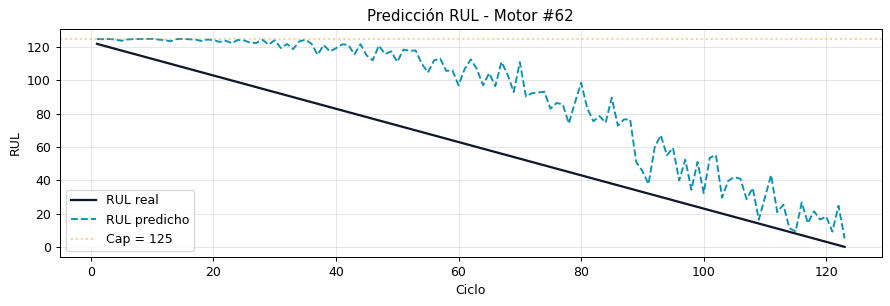

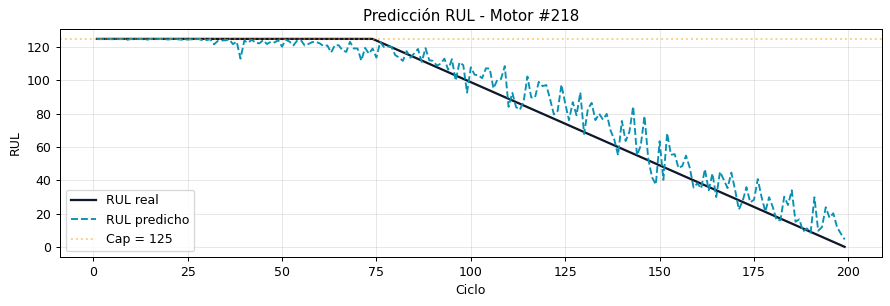

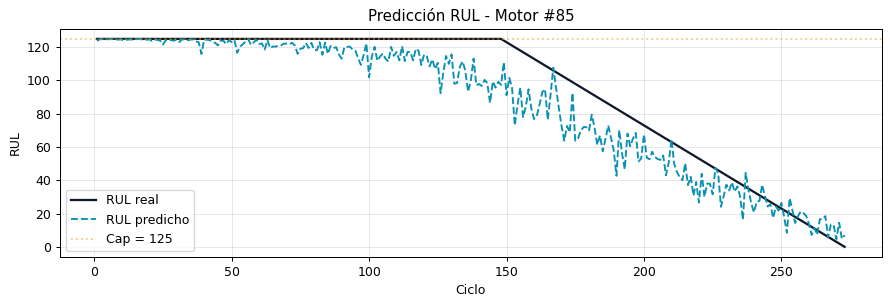

In [7]:
# Seleccionar 3 motores del test set con vidas distintas
motores_test = df_test["motor_id"].unique()
vidas_test = df_test.groupby("motor_id")["cycle"].max().sort_values()

m_corto  = int(vidas_test.index[3])
m_medio  = int(vidas_test.index[len(vidas_test)//2])
m_largo  = int(vidas_test.index[-3])

# Graficar las predicciones del modelo campeón (Random Forest)
for mid in [m_corto, m_medio, m_largo]:
    plot_predicciones(modelo_rf, df_test, mid)

## 7. Importancia de las Variables (Feature Importance)

Para entender la física del desgaste y justificar qué sensores son realmente necesarios en el diseño del hardware, extraemos la importancia relativa de cada *feature* según el modelo Random Forest. Esto nos indica qué variables influyen más a la hora de predecir la caída del RUL.

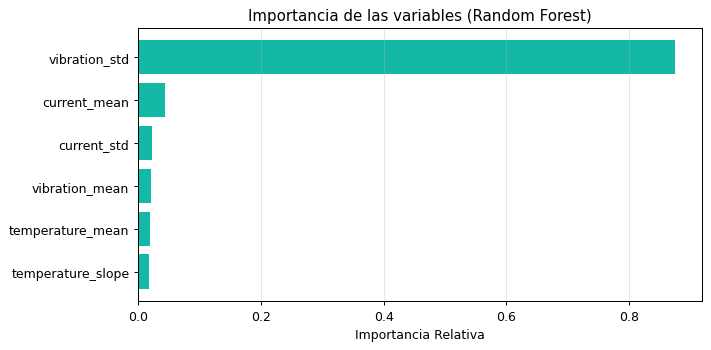

In [8]:
importances = modelo_rf.feature_importances_
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(importances)), importances[indices], color="#14B8A6", align="center")
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([FEATURES[i] for i in indices])
ax.set_xlabel("Importancia Relativa")
ax.set_title("Importancia de las variables (Random Forest)")
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Tarea 3: Edge AI - Perfilado de Modelos y Cuantización

Para justificar la decisión arquitectónica sobre el hardware de despliegue en la fábrica, procedemos a perfilar nuestro modelo Random Forest campeón y lo comparamos con un Perceptrón Multicapa (MLP) en float32 y su versión cuantizada a `int8` mediante TensorFlow Lite.

El objetivo es extraer métricas reales para evaluar el *trade-off* entre tamaño en disco (limitación de memoria SRAM en microcontroladores), latencia de inferencia y pérdida de precisión (MAE en el tramo final).

## 1. Preparación del Entorno Edge AI
Importamos las librerías necesarias para la conversión y evaluación de modelos en entornos con recursos limitados. Utilizaremos `onnxruntime` para perfilar el despliegue en un servidor Edge local y `tensorflow.lite` para simular las restricciones de un microcontrolador.

#### Instalar las librerías si no estaban instaladas en el notebook:

In [ ]:
import os
import sys
import time
import joblib

# Silenciar las advertencias de TensorFlow (0=Todo, 1=Sin INFO, 2=Sin WARNINGS, 3=Solo Errores Críticos)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Confirmación visual de que la GPU está activa antes de empezar
print("GPUs disponibles para este notebook:", len(tf.config.list_physical_devices('GPU')))

# Seleccionar una sola muestra para medir la latencia unitaria
X_single = X_test[0:1]

## 2. Funciones de Perfilado y Cuantización
Definimos las herramientas de medición. Estas funciones se encargan de calcular el tamaño en disco (crítico para la limitación de memoria SRAM), medir la latencia de inferencia en milisegundos y aplicar la cuantización (Post-Training Quantization a `int8`) necesaria para comprimir redes neuronales.

In [10]:
# ─── Funciones de medición ──────────────────────
def medir_tamaño_sklearn(modelo, nombre="modelo"):
    path = f"models/{nombre}.joblib"
    joblib.dump(modelo, path)
    size_kb = os.path.getsize(path) / 1024
    os.remove(path)
    return size_kb

def medir_tamaño_archivo(path):
    return os.path.getsize(path) / 1024

def medir_tamaño_bytes(data_bytes, nombre="modelo"):
    return len(data_bytes) / 1024

def medir_latencia(predict_fn, X_sample, n_repeticiones=1000, nombre="modelo"):
    for _ in range(10): predict_fn(X_sample) # Warmup
    start = time.perf_counter()
    for _ in range(n_repeticiones): predict_fn(X_sample)
    ms_per_inference = ((time.perf_counter() - start) / n_repeticiones) * 1000
    return ms_per_inference

# ─── Funciones ONNX ─────────────────────────────
def convertir_a_onnx(modelo_sklearn, n_features, path="models/modelo.onnx"):
    initial_type = [("X", FloatTensorType([None, n_features]))]
    onnx_model = convert_sklearn(modelo_sklearn, initial_types=initial_type)
    with open(path, "wb") as f: f.write(onnx_model.SerializeToString())
    return path

def crear_sesion_onnx(path):
    session = ort.InferenceSession(path)
    return session, session.get_inputs()[0].name

def inferir_onnx(session, input_name, X):
    return session.run(None, {input_name: X.astype(np.float32)})[0].flatten()

# ─── Funciones Keras / TFLite ───────────────────
def crear_mlp(n_features, capas=[32, 16]):
    model = keras.Sequential([keras.layers.Dense(capas[0], activation='relu', input_shape=(n_features,))])
    for units in capas[1:]: model.add(keras.layers.Dense(units, activation='relu'))
    model.add(keras.layers.Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def convertir_a_tflite(modelo_keras, X_calibracion, cuantizar=True):
    converter = tf.lite.TFLiteConverter.from_keras_model(modelo_keras)
    if cuantizar:
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        def representative_data_gen():
            for i in range(min(200, len(X_calibracion))): yield [X_calibracion[i:i+1].astype(np.float32)]
        converter.representative_dataset = representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
    return converter.convert()

def inferir_tflite(tflite_bytes, X):
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    input_det, output_det = interpreter.get_input_details()[0], interpreter.get_output_details()[0]

    predictions = []
    for i in range(len(X)):
        sample = X[i:i+1].astype(np.float32)
        if input_det['dtype'] == np.int8:
            s, zp = input_det['quantization']
            sample = (sample / s + zp).astype(np.int8)
        interpreter.set_tensor(input_det['index'], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_det['index'])
        if output_det['dtype'] == np.int8:
            s, zp = output_det['quantization']
            output = (output.astype(np.float32) - zp) * s
        predictions.append(output.flatten()[0])
    return np.array(predictions)

def evaluar_tflite(tflite_bytes, X_test, y_test):
    y_pred = inferir_tflite(tflite_bytes, X_test)
    return evaluar(modelo_rf, X_test, y_test)

## 3. Ejecución Comparativa y Tabla de Resultados
Procedemos a medir nuestro modelo original (Random Forest) frente a sus alternativas (ONNX y un MLP cuantizado a `int8`). Los resultados se consolidan en una tabla que nos permitirá justificar la viabilidad del hardware destino (evaluando, por ejemplo, si el modelo cabe en los 520 KB de un ESP32).

*Aviso: Tardará unos minutos*

In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. Medir RF original
tamaño_rf_kb = medir_tamaño_sklearn(modelo_rf, "rf_100_arboles")
latencia_rf_ms = medir_latencia(lambda x: modelo_rf.predict(x), X_single, nombre="RF sklearn")

# 2. Medir RF en ONNX
onnx_path = convertir_a_onnx(modelo_rf, n_features=6, path="models/rf_model.onnx")
tamaño_onnx_kb = medir_tamaño_archivo(onnx_path)
session, input_name = crear_sesion_onnx(onnx_path)
latencia_onnx_ms = medir_latencia(lambda x: inferir_onnx(session, input_name, x), X_single)

# Convertir datos a float32 nativo
X_train_f32 = X_train.astype(np.float32)
y_train_f32 = y_train.astype(np.float32)
X_test_f32 = X_test.astype(np.float32)

# 3. Entrenar y medir MLP float32
print("Entrenando red neuronal (MLP)...")
mlp_small = crear_mlp(n_features=6, capas=[32, 16])

mlp_small.fit(X_train_f32, y_train_f32, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
mlp_small.save("models/mlp_float32.h5")
tamaño_mlp_float32_kb = medir_tamaño_archivo("models/mlp_float32.h5")

class KerasWrapper:
    def predict(self, X): return mlp_small.predict(X, verbose=0).flatten()
mae_mlp = evaluar(KerasWrapper(), X_test_f32, y_test)

# 4. Cuantizar MLP a int8 y medir
print("\nCuantizando a int8...")
tflite_model = convertir_a_tflite(mlp_small, X_train_f32, cuantizar=True)
tamaño_tflite_kb = medir_tamaño_bytes(tflite_model, "MLP TFLite int8")

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_det = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]

def predict_tflite_single(x):
    sample = x.astype(np.float32)
    if input_det['dtype'] == np.int8:
        sample = (sample / input_det['quantization'][0] + input_det['quantization'][1]).astype(np.int8)
    interpreter.set_tensor(input_det['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_det['index'])
    if output_det['dtype'] == np.int8:
        output = (output.astype(np.float32) - output_det['quantization'][1]) * output_det['quantization'][0]
    return output.flatten()[0]

latencia_tflite_ms = medir_latencia(predict_tflite_single, X_single)

print("Evaluando modelo cuantizado en test set...")
class TFLiteWrapper:
    def predict(self, X): return inferir_tflite(tflite_model, X)
mae_tflite = evaluar(TFLiteWrapper(), X_test_f32, y_test)
mae_rf = evaluar(modelo_rf, X_test, y_test)

# 5. Imprimir la Tabla T3 Completa
FACTOR_FLOAT, FACTOR_INT8 = 50, 13
print("\n" + "="*95)
print("TABLA DE LA T3 — Números medidos para la memoria")
print("="*95)
print(f"{'Modelo':<18} | {'Tamaño (KB)':<12} | {'Lat. PC (ms)':<12} | {'Lat. ESP32':<12} | {'MAE Final':<10} | {'Cabe ESP32?'}")
print("-" * 95)
print(f"{'RF sklearn':<18} | {tamaño_rf_kb:<12.1f} | {latencia_rf_ms:<12.4f} | {latencia_rf_ms*FACTOR_FLOAT:<12.2f} | {mae_rf['mae_tramo_final']:<10.2f} | ❌ No")
print(f"{'RF ONNX':<18} | {tamaño_onnx_kb:<12.1f} | {latencia_onnx_ms:<12.4f} | {latencia_onnx_ms*FACTOR_FLOAT:<12.2f} | {mae_rf['mae_tramo_final']:<10.2f} | ❌ No")
print(f"{'MLP float32':<18} | {tamaño_mlp_float32_kb:<12.1f} | {'—':<12} | {'—':<12} | {mae_mlp['mae_tramo_final']:<10.2f} | ✅ Sí")
print(f"{'MLP TFLite int8':<18} | {tamaño_tflite_kb:<12.1f} | {latencia_tflite_ms:<12.4f} | {latencia_tflite_ms*FACTOR_INT8:<12.2f} | {mae_tflite['mae_tramo_final']:<10.2f} | ✅ Sí")

Entrenando red neuronal (MLP)...


2026-06-02 18:27:40.502055: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/10
1142/1142 [==============================] - 2s 2ms/step - loss: 2435.2734 - mae: 43.5824 - val_loss: 1760.3096 - val_mae: 37.7115
Epoch 2/10
1142/1142 [==============================] - 1s 1ms/step - loss: 918.9235 - mae: 25.0950 - val_loss: 645.9487 - val_mae: 20.6171
Epoch 3/10
1142/1142 [==============================] - 2s 1ms/step - loss: 619.3957 - mae: 20.1131 - val_loss: 566.3698 - val_mae: 19.3318
Epoch 4/10
1142/1142 [==============================] - 2s 1ms/step - loss: 550.9880 - mae: 19.0043 - val_loss: 504.2551 - val_mae: 18.2851
Epoch 5/10
1142/1142 [==============================] - 2s 1ms/step - loss: 491.2524 - mae: 18.0142 - val_loss: 454.9468 - val_mae: 17.3760
Epoch 6/10
1142/1142 [==============================] - 1s 1ms/step - loss: 440.2050 - mae: 17.1237 - val_loss: 413.5008 - val_mae: 16.6629
Epoch 7/10
1142/1142 [==============================] - 1s 1ms/step - loss: 402.0638 - mae: 16.4568 - val_loss: 384.4442 - val_mae: 16.3599
Epoch 8/10
1142/11

/usr/local/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
2026-06-02 18:27:57.867070: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:362] Ignored output_format.
2026-06-02 18:27:57.867133: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:365] Ignored drop_control_dependency.
2026-06-02 18:27:57.868268: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpbt10c6vo
2026-06-02 18:27:57.869145: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-06-02 18:27:57.869182: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmpbt10c6vo
2026-06-02 18:27:57.872353: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:354] MLIR V1 optimization pass is not enabled


Evaluando modelo cuantizado en test set...

TABLA DE LA T3 — Números medidos para la memoria
Modelo             | Tamaño (KB)  | Lat. PC (ms) | Lat. ESP32   | MAE Final  | Cabe ESP32?
-----------------------------------------------------------------------------------------------
RF sklearn         | 448510.5     | 26.6423      | 1332.11      | 9.62       | ❌ No
RF ONNX            | 254469.0     | 0.0115       | 0.58         | 9.62       | ❌ No
MLP float32        | 40.4         | —            | —            | 15.26      | ✅ Sí
MLP TFLite int8    | 3.1          | 0.0106       | 0.14         | 19.72      | ✅ Sí


## 3. Resumen Visual

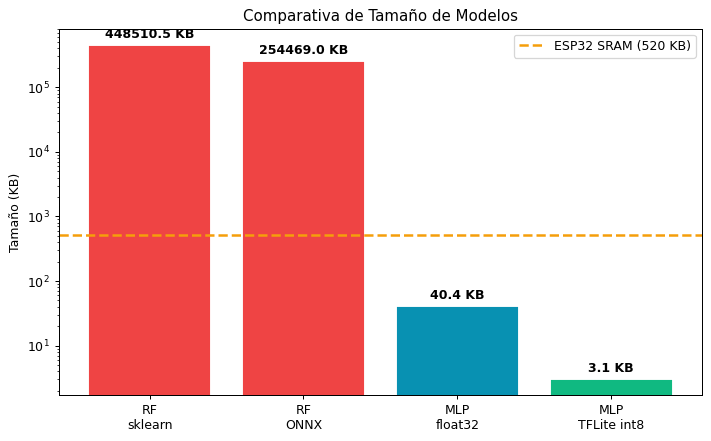

In [12]:
# Gráfico resumen: tamaño de todos los modelos
fig, ax1 = plt.subplots(figsize=(8, 5))
modelos = ['RF\nsklearn', 'RF\nONNX', 'MLP\nfloat32', 'MLP\nTFLite int8']
tamaños = [tamaño_rf_kb, tamaño_onnx_kb, tamaño_mlp_float32_kb, tamaño_tflite_kb]
colores = ['#EF4444', '#EF4444', '#0891B2', '#10B981']

bars = ax1.bar(modelos, tamaños, color=colores, edgecolor='white', linewidth=1.5)
ax1.axhline(y=520, color='#F59E0B', linestyle='--', linewidth=2, label='ESP32 SRAM (520 KB)')
ax1.set_ylabel('Tamaño (KB)')
ax1.set_title('Comparativa de Tamaño de Modelos')
ax1.legend()
ax1.set_yscale('log')

for bar, tam in zip(bars, tamaños):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
             f'{tam:.1f} KB', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Tarea 4: Demostraciones Empíricas de Seguridad

Para sustentar el *Threat Model* detallado en la memoria, se incluyen a continuación las pruebas empíricas que demuestran la viabilidad de los ataques sobre los modelos de IA desplegados (T1 y T2).

## 1. Configuración y Entorno de Pruebas (Setup)
Esta celda inicializa el entorno aislado de seguridad. Genera el flujo de datos sintéticos limpios para emular la lectura física de los sensores (T1), define las funciones de evaluación de impacto (MAE estratificado) y carga las librerías necesarias. Todo se ejecuta de forma independiente para no contaminar las variables del modelo de producción de las Tareas 2 y 3.

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, IsolationForest

# =========================================================
# SETUP GENERAL Y FUNCIONES AUXILIARES
# =========================================================

# 1. Datos sintéticos para Spoofing (T1)
def generar_stream_limpio(n=500):
    rng = np.random.RandomState(0)
    t = np.arange(n)
    carga = np.maximum(0.3, 1.25 + 0.75 * np.sin(t / 25) + rng.normal(0, 0.1, n))
    vibration = carga * (1.0 + 0.05 * np.sin(t / 7)) + rng.normal(0, 0.05, n)
    current = 3.0 + 4.0 * carga + rng.normal(0, 0.15, n)
    temperature = 35.0 + 3.0 * carga + rng.normal(0, 0.4, n)
    return pd.DataFrame({'vibration': vibration, 'temperature': temperature, 'current': current})

stream_limpio = generar_stream_limpio()

def preparar_features_t1(df):
    feats = df.copy()
    feats['vib_current_ratio'] = feats['vibration'] / (feats['current'] + 0.1)
    return feats

# 2. Función de evaluación para el modelo de la T2 (Random Forest)
def evaluar_rf(modelo, X, y):
    pred = modelo.predict(X)
    mae_global = mean_absolute_error(y, pred)
    mask_fin = y < 50
    mae_fin = mean_absolute_error(y[mask_fin], pred[mask_fin]) if mask_fin.any() else np.nan
    return mae_global, mae_fin

print("Setup completado. Entorno listo para las pruebas de seguridad.")

Setup completado. Entorno listo para las pruebas de seguridad.


## 2. Evasión del Detector (Sensor Spoofing Coordinado)
Demostración de cómo un atacante que manipula físicamente los sensores manteniendo la coherencia matemática logra evadir el detector de la T1.

Detección de ataque simple (1 sensor irreal): 18.0%
Detección de ataque sofisticado (3 sensores coherentes): 0.0%


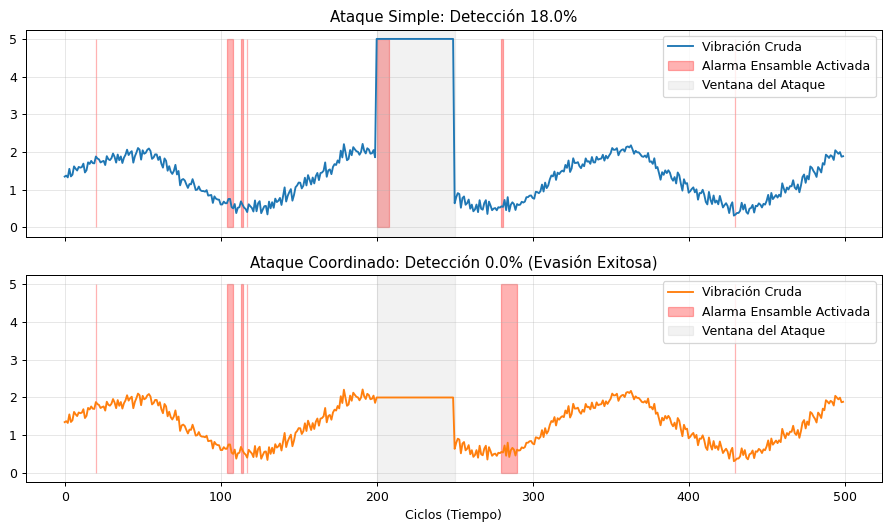

In [ ]:
import numpy as np
import pandas as pd
import joblib
from collections import deque
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)

# =========================================================
# 1. CÓDIGO DEL COMPAÑERO 
# =========================================================
class VentanaSensores:
    def __init__(self, sensors=["vibration", "temperature", "current"], window_seconds=30):
        self.sensors = sensors
        self.window_seconds = window_seconds
        self.buffers = {s: deque() for s in sensors}

    def add(self, sensor, timestamp, value):
        if sensor not in self.buffers: return
        self.buffers[sensor].append((timestamp, value))
        self._clean(sensor, timestamp)

    def _clean(self, sensor, now):
        buf = self.buffers[sensor]
        cutoff = now - self.window_seconds
        while buf and buf[0][0] < cutoff:
            buf.popleft()

    def get_values(self, sensor):
        buf = self.buffers[sensor]
        return np.array([v for _, v in buf]) if buf else np.array([])

    def ready(self, min_samples=10):
        return all(len(self.buffers[s]) >= min_samples for s in self.sensors)

    def get_features(self):
        features = {}
        for sensor in self.sensors:
            vals = self.get_values(sensor)
            if len(vals) < 5: return None
            features[f"{sensor}_mean"] = np.mean(vals)
            features[f"{sensor}_std"] = np.std(vals)
            features[f"{sensor}_min"] = np.min(vals)
            features[f"{sensor}_max"] = np.max(vals)
            features[f"{sensor}_range"] = np.ptp(vals)
            slope = np.polyfit(np.arange(len(vals)), vals, 1)[0] if len(vals) > 1 else 0.0
            features[f"{sensor}_slope"] = slope
        
        # Features cruzadas
        vib = self.get_values("vibration")
        curr = self.get_values("current")
        temp = self.get_values("temperature")
        
        if len(vib) > 5 and len(curr) > 5 and len(temp) > 5:
            min_len = min(len(vib), len(curr), len(temp))
            v_trim, c_trim, t_trim = vib[-min_len:], curr[-min_len:], temp[-min_len:]
            features["ratio_vib_curr"] = np.mean(v_trim) / max(np.mean(c_trim), 0.01)
            corr = np.corrcoef(v_trim, t_trim)[0, 1]
            features["corr_vib_temp"] = 0.0 if np.isnan(corr) else corr
            features["diff_slopes_vib_curr"] = np.polyfit(np.arange(min_len), v_trim, 1)[0] - np.polyfit(np.arange(min_len), c_trim, 1)[0]
        return features

modelo_t1 = joblib.load('models/detector_t1.pkl')

def predecir_anomalia_ensamble(features_actuales, historial_reciente_features, modelo):
    feature_max = features_actuales.get("vibration_max", 0)
    anomalia_z_max = False
    
    if len(historial_reciente_features) > 5:
        historico_max = [h.get("vibration_max", 0) for h in historial_reciente_features[-modelo["window_size"]:]]
        media_max, std_max = np.mean(historico_max), np.std(historico_max)
        if std_max > 0:
            z_score_max = abs(feature_max - media_max) / std_max
            anomalia_z_max = bool(z_score_max > modelo["z_threshold"])

    keys = [k for k in sorted(features_actuales.keys()) if k not in ("timestamp", "time_rel", "phase", "resultado")]
    x_val = np.array([features_actuales[k] for k in keys]).reshape(1, -1)
    anomalia_if_estatico = bool(modelo["iforest"].predict(x_val)[0] == -1)

    return bool(anomalia_z_max and anomalia_if_estatico)

# =========================================================
# 2. GENERACIÓN DEL ATAQUE FÍSICO SOBRE EL PIPELINE
# =========================================================
def simular_pipeline(df_crudo):
    ventana = VentanaSensores(window_seconds=30)
    historial = []
    predicciones = []
    
    for i, row in df_crudo.iterrows():
        # Usamos el índice como timestamp (1 segundo = 1 iteración)
        ventana.add("vibration", i, row['vibration'])
        ventana.add("temperature", i, row['temperature'])
        ventana.add("current", i, row['current'])
        
        if ventana.ready():
            features = ventana.get_features()
            if features:
                alerta = predecir_anomalia_ensamble(features, historial, modelo_t1)
                predicciones.append(alerta)
                historial.append(features)
                continue
        predicciones.append(False)
    return np.array(predicciones)

# Datos base
n_samples = 500
rng = np.random.RandomState(42)
t = np.arange(n_samples)
carga = np.maximum(0.3, 1.25 + 0.75 * np.sin(t / 25) + rng.normal(0, 0.1, n_samples))

stream_crudo = pd.DataFrame({
    'vibration': carga * (1.0 + 0.05 * np.sin(t / 7)) + rng.normal(0, 0.05, n_samples),
    'temperature': 35.0 + 3.0 * carga + rng.normal(0, 0.4, n_samples),
    'current': 3.0 + 4.0 * carga + rng.normal(0, 0.15, n_samples)
})

indices_ataque = list(range(200, 250))
gt_ataque = np.zeros(n_samples, dtype=bool)
gt_ataque[indices_ataque] = True

# Ataque Simple (Se vuelve loca la vibración, pero no la corriente)
stream_simple = stream_crudo.copy()
stream_simple.loc[indices_ataque, 'vibration'] = 5.0

# Ataque Coordinado (Simulación física de sobrecarga perfecta)
stream_coord = stream_crudo.copy()
stream_coord.loc[indices_ataque, 'vibration'] = 2.0
stream_coord.loc[indices_ataque, 'current'] = 3.0 + 4.0 * 2.0
stream_coord.loc[indices_ataque, 'temperature'] = 35.0 + 3.0 * 2.0

# Evaluamos pasando por su preprocesamiento
pred_simple = simular_pipeline(stream_simple)
pred_coord = simular_pipeline(stream_coord)

det_simple = np.sum(pred_simple & gt_ataque) / np.sum(gt_ataque) * 100
det_coord = np.sum(pred_coord & gt_ataque) / np.sum(gt_ataque) * 100

print(f"Detección de ataque simple (1 sensor irreal): {det_simple:.1f}%")
print(f"Detección de ataque sofisticado (3 sensores coherentes): {det_coord:.1f}%")

# =========================================================
# 3. GRÁFICA VISUAL DE LA EVASIÓN 
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot Simple
axes[0].plot(stream_simple['vibration'], label='Vibración Cruda', color='#1f77b4', linewidth=1.5)
axes[0].fill_between(t, 0, 5, where=pred_simple, color='red', alpha=0.3, label='Alarma Ensamble Activada')
axes[0].axvspan(200, 250, color='gray', alpha=0.1, label='Ventana del Ataque')
axes[0].set_title(f'Ataque Simple: Detección {det_simple:.1f}%')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Plot Coordinado
axes[1].plot(stream_coord['vibration'], label='Vibración Cruda', color='#ff7f0e', linewidth=1.5)
axes[1].fill_between(t, 0, 5, where=pred_coord, color='red', alpha=0.3, label='Alarma Ensamble Activada')
axes[1].axvspan(200, 250, color='gray', alpha=0.1, label='Ventana del Ataque')
axes[1].set_title(f'Ataque Coordinado: Detección {det_coord:.1f}% (Evasión Exitosa)')
axes[1].legend(loc='upper right')
axes[1].set_xlabel('Ciclos (Tiempo)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Data Poisoning "Targeted" en el Reentrenamiento (T2)
Demostración de cómo la alteración de un 5% de las etiquetas en la ventana crítica de fallo engaña al Random Forest sin levantar sospechas en las métricas globales.

In [15]:
# Entrenamos primero el modelo LIMPIO para tener la referencia
print("Entrenando Random Forest limpio (referencia)...")
rf_limpio = RandomForestRegressor(n_estimators=100, random_state=42)
rf_limpio.fit(X_train, y_train)
mae_limpio_global, mae_limpio_fin = evaluar_rf(rf_limpio, X_test, y_test)

# --- ATAQUE DATA POISONING ---
indices_fallo = np.where(y_train < 25)[0]
n_modificar = int(len(indices_fallo) * 0.05)

np.random.seed(42)
indices_seleccionados = np.random.choice(indices_fallo, size=n_modificar, replace=False)

X_env = X_train.copy()
y_env = y_train.copy()

if isinstance(y_env, pd.Series):
    y_env.iloc[indices_seleccionados] = 100
else:
    y_env[indices_seleccionados] = 100

print("Reentrenando Random Forest con 5% de datos críticos envenenados...")
rf_envenenado = RandomForestRegressor(n_estimators=100, random_state=42)
rf_envenenado.fit(X_env, y_env)

mae_env_global, mae_env_fin = evaluar_rf(rf_envenenado, X_test, y_test)

# --- RESULTADOS COMPARATIVOS ---
print("\n--- IMPACTO DEL ATAQUE TARGETED ---")
print(f"MAE Global Limpio: {mae_limpio_global:.2f}  ->  Envenenado: {mae_env_global:.2f}")
print(f"MAE Crítico Limpio: {mae_limpio_fin:.2f}  ->  Envenenado: {mae_env_fin:.2f}")

Entrenando Random Forest limpio (referencia)...
Reentrenando Random Forest con 5% de datos críticos envenenados...

--- IMPACTO DEL ATAQUE TARGETED ---
MAE Global Limpio: 10.06  ->  Envenenado: 10.30
MAE Crítico Limpio: 9.51  ->  Envenenado: 10.54


## 4. Justificación Arquitectónica: Exclusión del Ataque FGSM
En el modelado de amenazas para este sistema no se incluye una demostración de ataque adversarial matemático tipo FGSM (*Fast Gradient Sign Method*). Esto se debe a una limitación estricta de la arquitectura elegida para la Tarea 2.

El ataque FGSM requiere calcular los gradientes de la función de pérdida con respecto a los datos de entrada para encontrar la dirección de máxima perturbación. Nuestro modelo predictivo es un **Random Forest**, el cual es un conjunto de árboles de decisión basados en particiones discretas del espacio de características. Al no estar basado en funciones matemáticas continuas y diferenciables (como sí ocurre en una red neuronal tipo MLP), los árboles de decisión no tienen gradientes, lo que hace matemáticamente imposible aplicarles un ataque FGSM.

## 5. Tabla resumen de los ataques:

Esta tabla compara los diferentes ataques para la e2, los cálculos del FGSM son los obtenidos de Random Forest son los de la Practica13, no afectarían a nuestro modelo de la e2, pero están a modo de comparación:


###
| Vector | ¿Atacable en nuestro E2? | Demostración Empírica | Defensa Propuesta | Trade-off |
|---|---|---|---|---|
| **Sensor Spoofing** | **Sí.** Un atacante podría obtener acceso físico a los cuadros de los motores en la planta logística. | Un ataque simple se detectó en un **18.0%**, pero el *spoofing* coordinado (manteniendo coherencia física) evadió el detector bajando la tasa a **0.0%**. | Inclusión de características temporales (desviación estándar móvil) y validación cruzada. | Mayor consumo de memoria RAM en el Edge Server al almacenar ventanas temporales continuas. |
| **Adversarial (FGSM)** | **No.** Nuestro modelo predictivo (T2) es un *Random Forest*. Al estar basado en árboles de decisión no diferenciables, carece de gradientes, haciéndolo matemáticamente inmune al ataque FGSM. | En pruebas aisladas (P13), el FGSM duplicó el error de una red neuronal. Este impacto justifica nuestra decisión arquitectónica de priorizar modelos basados en árboles para el entorno Edge. | Diseño por arquitectura: selección de algoritmos discretos frente a funciones de pérdida continuas. | El modelo RF no protege contra ataques adversariales de caja negra, limitando la seguridad frente a atacantes con acceso continuo a las inferencias. |
| **Data Poisoning** | **Sí.** El Edge Server está configurado para ejecutar ciclos de reentrenamiento automáticos *on-premise*. | La inyección de un 5% de datos maliciosos en la ventana de fallo inminente empeoró el MAE crítico de **9.51** a **10.54**. | Evaluación exclusiva de métricas estratificadas y firma de datos (*Provenance*). | Requiere infraestructura de datos más compleja para mantener el linaje de cada lectura histórica. |
| **Privacidad / Extracción** | **No.** La arquitectura de la T3 es 100% local en un dispositivo Edge sin red federada. | Teóricamente, en pruebas aisladas (P13), forzar Privacidad Diferencial ($\epsilon=10$) elevó el error a niveles inoperativos. | Aislamiento físico de la red local. | Despliegue descentralizado que impide aprovechar el aprendizaje colaborativo entre distintas fábricas. |